In [16]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

In [17]:
# QUESTION 1: Chargement et interpolation linéaire

# Chargement du CSV
df = pd.read_csv("JNJ DEBT.csv")

# Garder les colonnes pertinentes
df = df[['datadate', 'dlcq', 'dlttq']]
df['datadate'] = pd.to_datetime(df['datadate'])
df = df.sort_values('datadate').reset_index(drop=True)

# Construire L_t trimestrielle
df['L_t'] = df['dlcq'] + 0.5 * df['dlttq']

print("Données trimestrielles :")
print(df[['datadate', 'dlcq', 'dlttq', 'L_t']])

# Interpolation linéaire quotidienne
daily_idx = pd.date_range(df['datadate'].min(), df['datadate'].max(), freq='D')

df_daily = df.set_index('datadate')[['L_t']].reindex(daily_idx)
df_daily.index.name = 'date'

df_daily['L_t'] = df_daily['L_t'].interpolate(method='linear')

df_daily

Données trimestrielles :
    datadate     dlcq    dlttq      L_t
0 2024-12-31   5983.0  30651.0  21308.5
1 2025-03-31  13897.0  38355.0  33074.5
2 2025-06-30  11526.0  39235.0  31143.5
3 2025-09-30   6387.0  39408.0  26091.0
4 2025-12-31   8495.0  39438.0  28214.0


,L_t
date,
2024-12-31,21308.500000
2025-01-01,21439.233333
2025-01-02,21569.966667
2025-01-03,21700.700000
2025-01-04,21831.433333
...,...
2025-12-27,28121.695652
2025-12-28,28144.771739
2025-12-29,28167.847826


In [18]:
# QUESTION 2: Capitalisation boursiere (CRSP)

# Chargement du CSV
df_mkt = pd.read_csv("JNJ MKTCAP.csv")

# Nettoyer et preparer
df_mkt['DlyCalDt'] = pd.to_datetime(df_mkt['DlyCalDt'])
df_mkt = df_mkt.sort_values('DlyCalDt').reset_index(drop=True)

# DlyCap est en milliers $ -> convertir en dollars
df_mkt = df_mkt[['DlyCalDt', 'DlyCap']].rename(columns={
    'DlyCalDt' : 'date',
    'DlyCap'   : 'Market_Cap'
})
df_mkt['Market_Cap'] = df_mkt['Market_Cap'] * 1000

df_mkt = df_mkt.set_index('date')

df_mkt

,Market_Cap
date,
2024-10-01,3.899495e+11
2024-10-02,3.879755e+11
2024-10-03,3.863627e+11
2024-10-04,3.858571e+11
2024-10-07,3.840276e+11
...,...
2025-12-24,5.006033e+11
2025-12-26,5.002419e+11
2025-12-29,5.000733e+11


In [23]:
# QUESTION 3: Modele de Merton (approche iterative)

# 3.1 Chargement du taux sans risque (FRED DGS1)
df_rf = pd.read_csv("DGS1.csv")
df_rf.columns = ['date', 'rf']
df_rf['date'] = pd.to_datetime(df_rf['date'])
df_rf['rf'] = pd.to_numeric(df_rf['rf'], errors='coerce') / 100
df_rf = df_rf.dropna()
df_rf = df_rf.set_index('date')

# Filtrer sur la même période que le market cap
df_rf = df_rf.loc['2024-10-01':'2025-12-31']

# 3.2 Aligner les jours de negociation
common_dates = df_mkt.index.intersection(df_rf.index)

# Commencer au 2024-12-31 (première date de L_t)
common_dates = common_dates[common_dates >= '2024-12-31']

df_mkt_aligned = df_mkt.loc[common_dates]
df_rf_aligned  = df_rf.loc[common_dates]
df_L_aligned   = df_daily.reindex(common_dates).ffill()

print(f"{len(common_dates)} jours de negociation communs")
print(f"Periode : {common_dates.min().date()} - {common_dates.max().date()}")
print(f"Taille E: {len(df_mkt_aligned)}, r: {len(df_rf_aligned)}, L: {len(df_L_aligned)}")

# 3.3 Parametres
E = df_mkt_aligned['Market_Cap'].values          
r = df_rf_aligned['rf'].values
L = df_L_aligned['L_t'].values * 1_000_000     
T = 1

# 3.4 Fonctions Black-Scholes (Merton)
def merton_equity(V, L, r, sigma, T):
    d1 = (np.log(V / L) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return V * norm.cdf(d1) - L * np.exp(-r * T) * norm.cdf(d2)

# 3.5 Approche iterative
N = len(E)

# Initialisation
sigma_E = np.std(np.diff(np.log(E))) * np.sqrt(252)
sigma_A = sigma_E * np.mean(E) / (np.mean(E) + np.mean(L))
V_A     = E + L

tol      = 1e-6
max_iter = 1000

for iteration in range(max_iter):
    sigma_A_old = sigma_A

    V_A_new = np.zeros(N)
    for i in range(N):
        def eq(Va, i=i):
            return merton_equity(Va, L[i], r[i], sigma_A, T) - E[i]
        V_A_new[i] = fsolve(eq, V_A[i])[0]

    log_ret = np.diff(np.log(V_A_new))
    sigma_A = np.std(log_ret) * np.sqrt(252)
    V_A     = V_A_new

    if abs(sigma_A - sigma_A_old) < tol:
        print(f"Convergence atteinte apres {iteration+1} iterations")
        break

# 3.6 Resultats
print(f"Volatilite des actifs (sigma_A): {sigma_A:.4f}")
print(f"Valeur moyenne des actifs: {np.mean(V_A):,.0f} $")
print(f"Valeur finale des actifs: {V_A[-1]:,.0f} $")

df_results = pd.DataFrame({
    'E'   : E,
    'L'   : L,
    'r'   : r,
    'V_A' : V_A
}, index=common_dates)

print(f"Volatilite des actions (sigma_E): {sigma_E:.4f}")

df_results

249 jours de negociation communs
Periode : 2024-12-31 - 2025-12-31
Taille E: 249, r: 249, L: 249
Convergence atteinte apres 2 iterations
Volatilite des actifs (sigma_A): 0.1841
Valeur moyenne des actifs: 436,795,602,463 $
Valeur finale des actifs: 525,852,640,727 $
Volatilite des actions (sigma_E): 0.1970


,E,L,r,V_A
date,,,,
2024-12-31,3.481904e+11,2.130850e+10,0.0416,3.686307e+11
2025-01-02,3.467459e+11,2.156997e+10,0.0417,3.674349e+11
2025-01-03,3.471552e+11,2.170070e+10,0.0418,3.679675e+11
2025-01-06,3.458791e+11,2.209290e+10,0.0417,3.670697e+11
2025-01-07,3.520667e+11,2.222363e+10,0.0419,3.733784e+11
...,...,...,...,...
2025-12-24,5.006033e+11,2.805247e+10,0.0350,5.276909e+11
2025-12-26,5.002419e+11,2.809862e+10,0.0349,5.273768e+11
2025-12-29,5.000733e+11,2.816785e+10,0.0348,5.272777e+11


Extrait de la frontiere de defaut (colonnes 0,1,5,10,20,30) :
                      0             1             5             10  \
date                                                                 
2024-12-31  2.081679e+10  2.130850e+10  2.327534e+10  2.573389e+10   
2025-01-02  2.108301e+10  2.156997e+10  2.351781e+10  2.595260e+10   
2025-01-03  2.121612e+10  2.170070e+10  2.363904e+10  2.606196e+10   
2025-01-06  2.161544e+10  2.209290e+10  2.400273e+10  2.639002e+10   
2025-01-07  2.174855e+10  2.222363e+10  2.412396e+10  2.649938e+10   

                      20            30  
date                                    
2024-12-31  3.065100e+10  3.556811e+10  
2025-01-02  3.082220e+10  3.569180e+10  
2025-01-03  3.090780e+10  3.575364e+10  
2025-01-06  3.116460e+10  3.593918e+10  
2025-01-07  3.125020e+10  3.600102e+10  


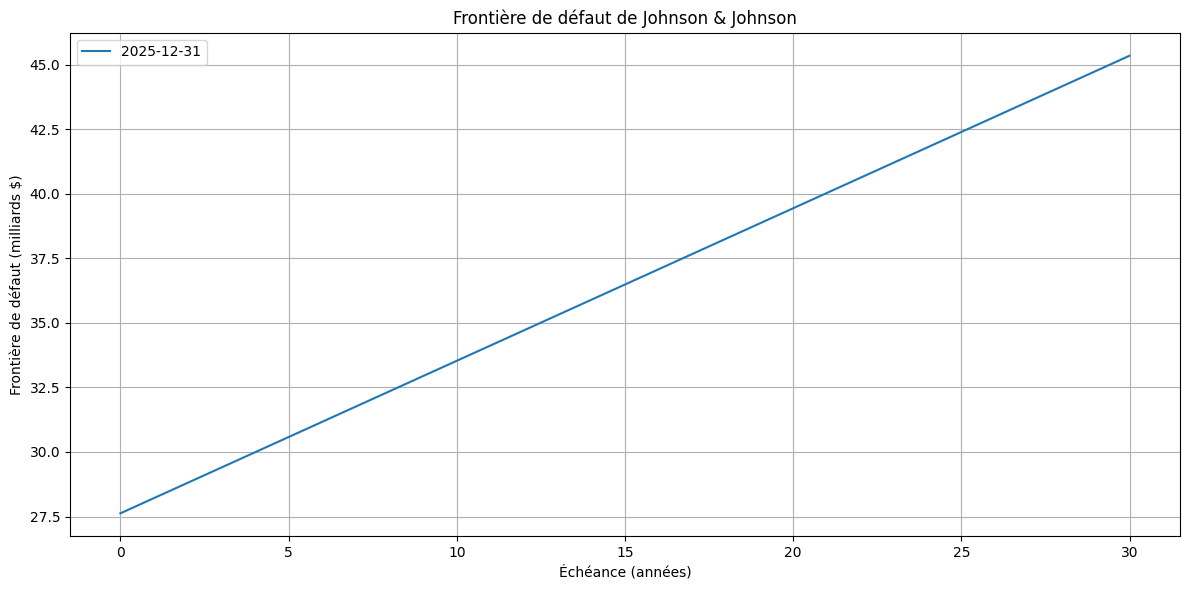

In [ ]:
# QUESTION 4: Frontiere de defaut (interpolation/extrapolation)

# 4.1 Points de defaut connus
df_debt = pd.read_csv("JNJ DEBT.csv")
df_debt['datadate'] = pd.to_datetime(df_debt['datadate'])
df_debt = df_debt.sort_values('datadate').reset_index(drop=True)

# Interpolation lineaire quotidienne de DLTTQ
daily_idx = pd.date_range(df_debt['datadate'].min(), df_debt['datadate'].max(), freq='D')
df_dlttq_daily = df_debt.set_index('datadate')[['dlttq']].reindex(daily_idx)
df_dlttq_daily.index.name = 'date'
df_dlttq_daily['dlttq'] = df_dlttq_daily['dlttq'].interpolate(method='linear')

# Convertir en dollars (millions -> dollars)
df_dlttq_daily['dlttq'] = df_dlttq_daily['dlttq'] * 1_000_000

# Aligner sur common_dates
dlttq_aligned = df_dlttq_daily.reindex(common_dates).ffill()['dlttq'].values
lt_aligned    = df_L_aligned['L_t'].values * 1_000_000

# 4.2 Construire la frontiere de defaut pour chaque date
maturities = np.arange(0, 31)

def default_boundary(L1, L20, maturities):
    boundary = np.zeros(len(maturities))
    for j, T in enumerate(maturities):
        boundary[j] = L1 + (L20 - L1) * (T - 1) / (20 - 1)
    return boundary

# Calculer la frontière pour chaque jour
df_boundary = pd.DataFrame(index=common_dates, columns=maturities, dtype=float)

for i, date in enumerate(common_dates):
    L1  = lt_aligned[i]
    L20 = dlttq_aligned[i]
    df_boundary.loc[date] = default_boundary(L1, L20, maturities)

print("Extrait de la frontiere de defaut (colonnes 0,1,5,10,20,30) :")
print(df_boundary[[0, 1, 5, 10, 20, 30]].head())

# 4.3 Visualisation
plt.figure(figsize=(12, 6))
# Tracer la frontière pour la date finale de la série
date = common_dates[-1]
plt.plot(maturities, df_boundary.loc[date].values / 1e9, label=date.strftime('%Y-%m-%d'))
plt.xlabel("Échéance (années)")
plt.ylabel("Frontière de défaut (milliards $)")
plt.title("Frontière de défaut de Johnson & Johnson")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Courbe des taux sans risque au 2026-01-02 :
 1 ans : 3.4700%
 2 ans : 3.4700%
 3 ans : 3.5500%
 5 ans : 3.7400%
 7 ans : 3.9500%
10 ans : 4.1900%
20 ans : 4.8100%
30 ans : 4.8600%
Structure par terme des ecarts de credit (2026-01-02) :
                Taux sans risque (%)  Écart de crédit (bps)
Échéance (ans)                                             
1                              3.470           4.857226e-13
2                              3.470          -6.938894e-14
3                              3.550           1.387779e-13
4                              3.645           4.857226e-13
5                              3.740           4.253542e-11
6                              3.845           2.917389e-09
7                              3.950           5.816785e-08
8                              4.030           5.475501e-07
9                              4.110           3.074292e-06
10                             4.190           1.201047e-05
11                             4.252        

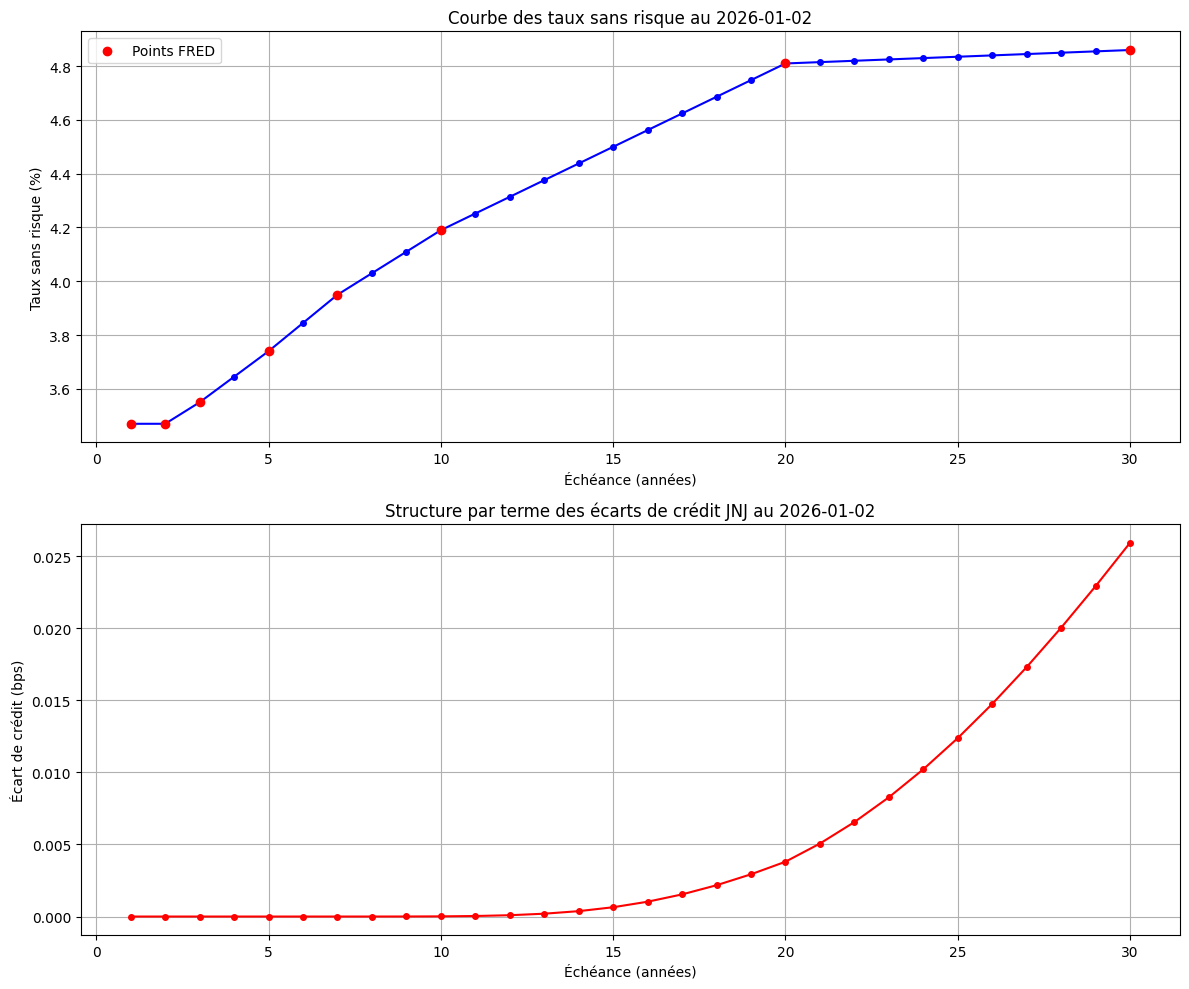

In [ ]:
# QUESTION 5: Structure par terme des ecarts de credit (Merton)

# 5.1 Chargement de la courbe des taux sans risque
taux_fichiers = {
    1 : "DGS1.csv",
    2 : "DGS2.csv",
    3 : "DGS3.csv",
    5 : "DGS5.csv",
    7 : "DGS7.csv",
    10: "DGS10.csv",
    20: "DGS20.csv",
    30: "DGS30.csv"
}

date_eval = pd.Timestamp('2026-01-02')

rf_curve = {}
for T, fichier in taux_fichiers.items():
    df_tmp = pd.read_csv(fichier)
    df_tmp.columns = ['date', 'rate']
    df_tmp['date'] = pd.to_datetime(df_tmp['date'])
    df_tmp['rate'] = pd.to_numeric(df_tmp['rate'], errors='coerce')
    df_tmp = df_tmp.dropna().set_index('date')
    rf_curve[T] = df_tmp.loc[date_eval, 'rate'] / 100

print("Courbe des taux sans risque au 2026-01-02 :")
for T, r in rf_curve.items():
    print(f"{T:2d} ans : {r*100:.4f}%")

# 5.2 Interpolation lineaire pour toutes les echeances 1 a 30 ans


maturities_known = np.array(list(rf_curve.keys()))
rates_known      = np.array(list(rf_curve.values()))

rf_interp  = interp1d(maturities_known, rates_known,
                      kind='linear', fill_value='extrapolate')
maturities_all = np.arange(1, 31)
rf_all         = rf_interp(maturities_all)

# 5.3 Parametres Merton au 2025-12-31
V_A_last    = V_A[-1]
sigma_A_est = sigma_A

# Frontiere de defaut au 2025-12-31
L_last = df_boundary.loc[common_dates[-1]].values  # indices 0 a 30

# 5.4 Calcul des ecarts de credit (formule correcte de Merton)
def merton_credit_spread(V, L, r, sigma, T):
    if L <= 0 or V <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(V / L) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Prix de l'obligation risquée (valeur actuelle de la dette)
    bond_price = L * np.exp(-r * T) * norm.cdf(d2) + V * norm.cdf(-d1)

    # Valeur nominale actualisée au taux sans risque
    face_value_pv = L * np.exp(-r * T)

    if bond_price <= 0 or face_value_pv <= 0:
        return np.nan

    # Taux de rendement de l'obligation risquée
    risky_yield = -np.log(bond_price / L) / T

    # Écart de crédit = taux risqué - taux sans risque
    spread = risky_yield - r
    return spread

spreads = []
for i, T in enumerate(maturities_all):
    L_T = L_last[T]   # frontière de défaut à l'échéance T (indices 0..30)
    r_T = rf_all[i]
    s   = merton_credit_spread(V_A_last, L_T, r_T, sigma_A_est, T)
    spreads.append(s * 10000)  # bps

spreads = np.array(spreads)

# 5.5 Resultats
df_spreads = pd.DataFrame({
    'Échéance (ans)'       : maturities_all,
    'Taux sans risque (%)' : rf_all * 100,
    'Écart de crédit (bps)': spreads
}).set_index('Échéance (ans)')

print("Structure par terme des ecarts de credit (2026-01-02) :")
print(df_spreads.to_string())

# 5.6 Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(maturities_all, rf_all * 100, 'b-o', markersize=4)
ax1.scatter(maturities_known, rates_known * 100, color='red', zorder=5, label='Points FRED')
ax1.set_xlabel("Échéance (années)")
ax1.set_ylabel("Taux sans risque (%)")
ax1.set_title("Courbe des taux sans risque au 2026-01-02")
ax1.legend()
ax1.grid(True)

ax2.plot(maturities_all, spreads, 'r-o', markersize=4)
ax2.set_xlabel("Échéance (années)")
ax2.set_ylabel("Écart de crédit (bps)")
ax2.set_title("Structure par terme des écarts de crédit JNJ au 2026-01-02")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [22]:
# Diagnostic
print(f"V_A_last : {V_A_last:,.0f}")
print(f"L_last[1] : {L_last[1]:,.0f}")
print(f"L_last[20] : {L_last[20]:,.0f}")
print(f"sigma_A : {sigma_A_est:.4f}")

V_A_last : 525,852,640,727
L_last[1] : 28,214,000,000
L_last[20] : 39,438,000,000
sigma_A : 0.1841
